In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.colors import BoundaryNorm

In [2]:
import pathlib
from os import path, getcwd

from tqdm import tqdm
import numpy as np


def read_data(parent_dir: pathlib.Path) -> (list, list):
    folders = [item for item in parent_dir.iterdir() if item.is_dir()]
    folders.sort()
    ws, hs, failure_probs = list(), list(), list()
    for folder in tqdm(folders):
        *_, w, h = folder.name.split('-')
        ws.append(float(w))
        hs.append(float(h))
        fp_output = folder / f'{folder.name}_out.csv'
        try:
            assert path.exists(fp_output), f'file does not exist {fp_output}'
        except AssertionError:
            continue
        mcs_output = np.genfromtxt(fp_output, delimiter=",", skip_header=1)

        N = np.shape(mcs_output)[0]

        # find all iterations that ignition occurred
        t_ig_ftp = mcs_output[:, 2]
        P_ig = sum(np.logical_and(t_ig_ftp > 0, t_ig_ftp < np.inf)) / N

        failure_probs.append(P_ig)
    return ws, hs, failure_probs


data = dict(
    br187_normal=read_data(pathlib.Path(getcwd(), 'br187')),
)

100%|██████████| 4000/4000 [03:29<00:00, 19.13it/s]


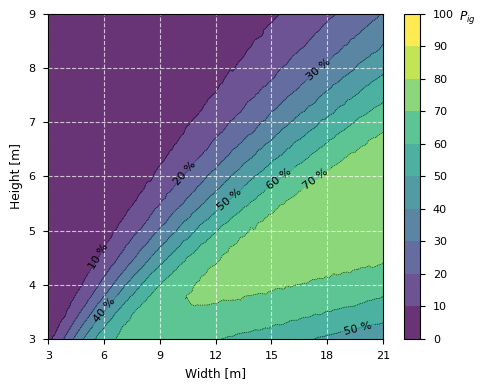

In [4]:
plt.style.use('seaborn-v0_8-paper')

x, y, z = data['br187_normal']
z = np.array(z) * 100.

# Create a triangulation
triang = tri.Triangulation(x, y)

# Define levels with increments of 10
levels = np.linspace(0, 100, 11)  # [0, 10, 20, ..., 100]

# Choose a built-in colormap
# Options: 'viridis', 'plasma', 'inferno', 'magma', 'cividis', 'turbo'
# Or sequential: 'Blues', 'Greens', 'Oranges', 'Purples', 'Reds'
# Or diverging: 'coolwarm', 'RdBu', 'RdYlBu', 'RdYlGn', 'spectral'
cmap = plt.get_cmap('viridis', 10)  # 10 discrete colors for 10 bands

# Create a BoundaryNorm to map values to colors
norm = BoundaryNorm(levels, 10)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(5, 4))

# Create contour lines
cs = ax.tricontour(
    x, y, z,
    levels=levels,
    linewidths=0.5, colors='black',
    linestyles='dotted', antialiased=True
)

# Create filled contours with exactly the levels we want
cf = ax.tricontourf(x, y, z, levels=levels, cmap=cmap, norm=norm, alpha=0.8)

# Add contour labels
ax.clabel(cs, cs.levels, inline=True, fmt=lambda x: f'{x:.0f} %', fontsize=8, manual=False, use_clabeltext=True)
ax.set_xlabel(r'Width [m]')
ax.set_ylabel('Height [m]')
ax.set_xlim(3, 21)
ax.set_ylim(3, 9)
ax.grid(True, linestyle='--', color='white', alpha=0.7)

ax.set_xticks([3, 6, 9, 12, 15, 18, 21])

# Create colorbar with ticks at each level
cbar = plt.colorbar(cf, ax=ax, ticks=levels)
cbar.set_label('$P_{ig}$', rotation=0, labelpad=10, y=1.015)

plt.tight_layout()
plt.show()

In [5]:
max(z) + 1

np.float64(80.59)